In [87]:
import yfinance as yf

In [88]:
stock_data = yf.download('AUB', start='2024-03-28', end='2026-03-28')

print(stock_data)

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker            AUB        AUB        AUB        AUB       AUB
Date                                                            
2024-03-28  32.639545  33.138703  32.556352  32.750469    703800
2024-04-01  32.195850  32.879883  32.001730  32.658036   1670200
2024-04-02  31.179041  31.844589  31.049630  31.678202   3636200
2024-04-03  30.550472  31.336190  30.393331  30.827783    537800
2024-04-04  30.689129  31.474843  30.661395  31.234508    434400
2024-04-05  30.938709  31.086609  30.430302  30.439548    308800
2024-04-08  31.428623  31.567280  31.086607  31.216018    339000
2024-04-09  31.585768  31.890812  31.299215  31.493332    310300
2024-04-10  30.005089  30.837024  29.589121  30.642907    494100
2024-04-11  29.903414  30.263922  29.552153  30.263922    339700
2024-04-12  29.635345  29.884926  29.422739  29.589124    380800
2024-04-15  29.468954  30.079041  29.210131  29.718537    273400
2024-04-16  29.395004  29

In [89]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


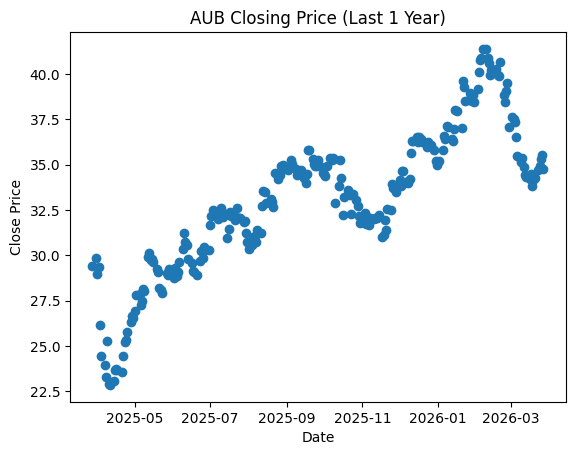

In [90]:
import matplotlib.pyplot as plot
import pandas as pd
last_year = stock_data.loc['2025-03-28':'2026-03-28']

plot.figure()
plot.scatter(last_year.index, last_year['Close'])
plot.title("AUB Closing Price (Last 1 Year)")
plot.xlabel("Date")
plot.ylabel("Close Price")
plot.show()

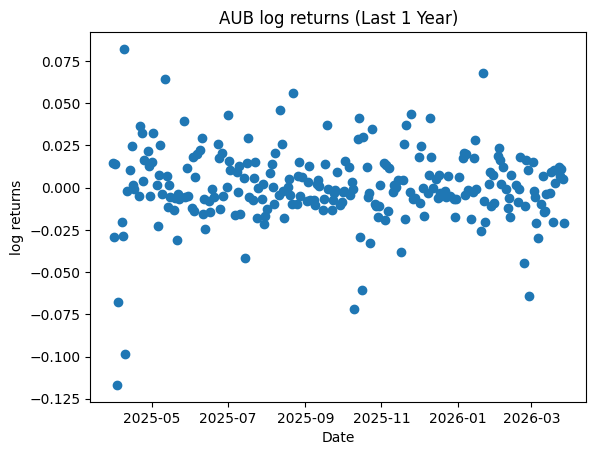

In [91]:
import numpy as np

log_returns = np.log(last_year['Close']/last_year['Close'].shift(1)).dropna()

plot.figure()
plot.scatter(last_year.index[1:], log_returns)
plot.title("AUB log returns (Last 1 Year)")
plot.xlabel("Date")
plot.ylabel("log returns")
plot.show()

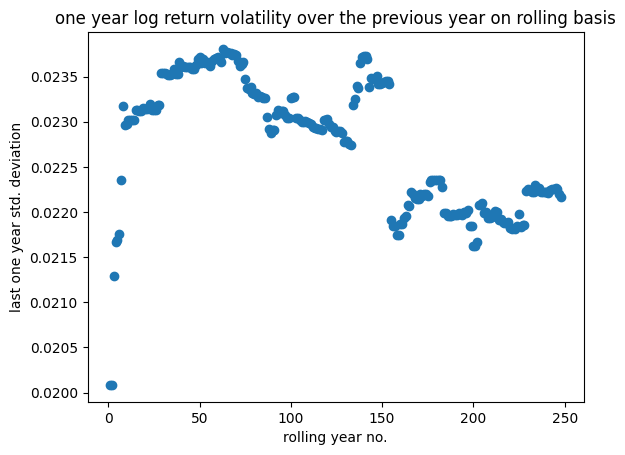

In [92]:
log_returns_2y = np.log(stock_data['Close']/stock_data['Close'].shift(1)).dropna()

log_return_rolling_vol = []
for i in range(len(log_returns_2y)):
    if i >= 252:
        rolling_year_return = log_returns_2y.iloc[i-252:i]
        rolling_year_vol_return = np.std(rolling_year_return)
        log_return_rolling_vol.append(rolling_year_vol_return)

plot.figure()
plot.scatter(range(1, len(log_return_rolling_vol)+1), log_return_rolling_vol)
plot.title('one year log return volatility over the previous year on rolling basis')
plot.xlabel('rolling year no.')
plot.ylabel('last one year std. deviation')
plot.show()

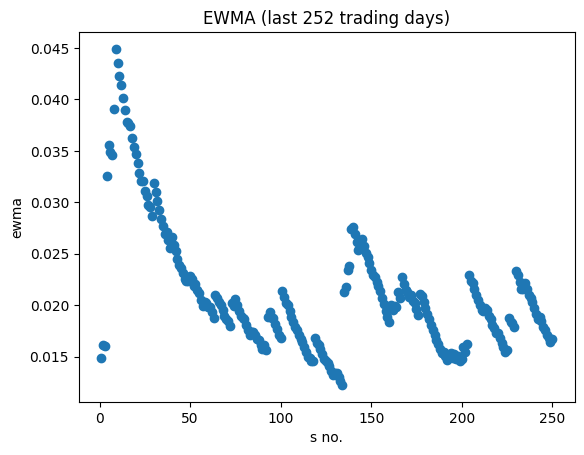

In [93]:
#EWMA 
dec_f = 0.94 # decaying factor

"""We use decaying factor = 0.94 because RiskMetrics (a company found by JP Morgan) found that this is an ideal decaying factor for
daily losses. Anything more would be too long a memory and anything less would be too volatile. It is the sweet spot to factor in 
shocks but ignore daily naoise."""

# initialsed variance anchor
var_ = log_returns.iloc[0]**2

ewma_var = []
ewma_vol = []

for return_ in log_returns.values:
    var_  = dec_f * var_ + (1 - dec_f) * return_**2
    ewma_var.append(var_)
    ewma_vol.append(np.sqrt(var_))

plot.figure()
plot.scatter(range(1, len(ewma_vol)+1), ewma_vol)
plot.title('EWMA (last 252 trading days)')
plot.xlabel('s no.')
plot.ylabel('ewma')
plot.show()




In [94]:
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
ewma_vol = sm.add_constant(ewma_vol)

my_model = sm.OLS(log_returns, ewma_vol).fit()
print(my_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    AUB   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1609
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.689
Time:                        13:57:21   Log-Likelihood:                 597.47
No. Observations:                 250   AIC:                            -1191.
Df Residuals:                     248   BIC:                            -1184.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.005      0.520      0.6

 Notes:
> R-squared = 0.001 means that 0.1% of the variablity in returns is explained by the ewma. That is very weak correlation.
> The estimated slope is -0.125, which shows a weak linear relationship.
> p-value = 57.4%, which means we would fail to reject null at a 10% level (being generous here), but ofcourse this requires distributional
assumptions like normality for the errors, but we haven't made any such assumptions.

In [96]:
vol = sm.add_constant(log_return_rolling_vol)

my_model1 = sm.OLS(log_returns[2:], vol).fit()
print(my_model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    AUB   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     3.151
Date:                Sun, 05 Apr 2026   Prob (F-statistic):             0.0771
Time:                        13:57:21   Log-Likelihood:                 594.31
No. Observations:                 248   AIC:                            -1185.
Df Residuals:                     246   BIC:                            -1178.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0784      0.045     -1.758      0.0

This is much more impressive than ewma fit. Even though the slope estimate is higher, the R-squared value is still 1.3% and std. error on the estimate is still higher. 

[*********************100%***********************]  1 of 1 completed

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.2922
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.592
Time:                        13:57:21   Log-Likelihood:                 37.264
No. Observations:                  37   AIC:                            -70.53
Df Residuals:                      35   BIC:                            -67.31
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0272      0.043      0.635      0.5

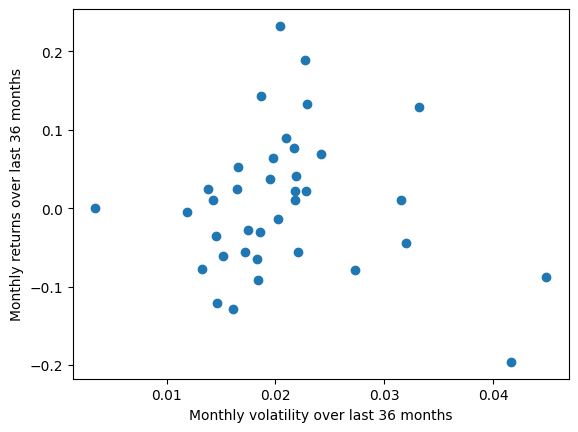

In [97]:
price_df = yf.download('AUB', start='2023-03-28', end='2026-03-28')

price_df['ret_daily'] = np.log(price_df['Close'] / price_df['Close'].shift(1))
price_df = price_df.dropna()

monthly_grp = price_df.groupby(pd.Grouper(freq='ME'))

ret_list = []
vol_list = []
month_index = []

for m_date, m_data in monthly_grp:
    if len(m_data) > 1:
        m_ret = np.log(m_data['Close'].iloc[-1] / m_data['Close'].iloc[0])
        m_vol = np.std(m_data['ret_daily'], ddof=1)
        
        ret_list.append(m_ret)
        vol_list.append(m_vol)
        month_index.append(m_date)

pred_var = sm.add_constant(vol_list)
res_var = ret_list

reg_model = sm.OLS(res_var, pred_var).fit()

print(reg_model.summary())

plot.figure()
plot.scatter(vol_list, ret_list)
plot.xlabel('Monthly volatility over last 36 months')
plot.ylabel('Monthly returns over last 36 months')
plot.show()

In [110]:
data = yf.download('AUB.AX', period='24mo', interval='1d')['Close']

ret_aub = np.log(data / data.shift(1))
ret_aub = ret_port.dropna()

lambda_ = 0.94 # explained rationale before

ewma_var1 = ret_aub.pow(2).ewm(alpha=(1 - lambda_)).mean() # using in-built function for ewma calculation
ewma_vol1 = np.sqrt(ewma_var1)

df = pd.concat([ret_aub, ewma_vol1], axis=1)
df.columns = ['returns', 'ewma_vol1']
df = df.dropna()

[*********************100%***********************]  1 of 1 completed


In [112]:
momentum = ret_aub.shift(1).rolling(window=21).sum()

df['momentum'] = momentum
df = df.dropna()

In [116]:
volume_data = yf.download('AUB.AX', period='24mo', interval='1d')['Volume']
volume_data = np.log(volume_data + 1) # avoiding 0 values to avoid -inf when taking log
df['liquidity'] = volume_data
df = df.dropna()

# df

[*********************100%***********************]  1 of 1 completed


In [117]:
x_vals = df[['ewma_vol1', 'momentum', 'liquidity']]
x_vals = sm.add_constant(x_vals)

y = df['returns']

model = sm.OLS(y, x_vals).fit(cov_type='HAC', cov_kwds={'maxlags':5}) # will tell in meeting can't write too much
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                    0.3727
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.773
Time:                        14:23:58   Log-Likelihood:                 1231.1
No. Observations:                 487   AIC:                            -2454.
Df Residuals:                     483   BIC:                            -2438.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0104      0.014      0.748      0.4

VERY INSIGNIFICANT RESULTS FOR ALL FACTORS

In [118]:
market_data = yf.download('^AXJO', period='24mo', interval='1d')['Close']
market_mov = np.log(market_data/market_data.shift(1)).dropna()
df_marketindex = pd.concat([ret_aub, ewma_vol1, momentum, volume_data, market_mov], axis=1)
df_marketindex.columns = ['returns', 'ewma_vol1', 'momentum', 'liquidity', 'market index']
df_marketindex = df_marketindex.dropna()

x_vals1 = df_marketindex[['ewma_vol1', 'momentum', 'liquidity','market index']]
x_vals1 = sm.add_constant(x_vals1)

y1 = df['returns']

model1 = sm.OLS(y1, x_vals1).fit(cov_type='HAC', cov_kwds={'maxlags':5}) # will tell in meeting can't write too much
print(model1.summary())

[*********************100%***********************]  1 of 1 completed

                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     13.89
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           9.86e-11
Time:                        14:36:10   Log-Likelihood:                 1252.7
No. Observations:                 487   AIC:                            -2495.
Df Residuals:                     482   BIC:                            -2475.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0050      0.014      0.363   


C:\Users\suhit\AppData\Local\Temp\ipykernel_23260\3175914019.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_marketindex = pd.concat([ret_aub, ewma_vol1, momentum, volume_data, market_mov], axis=1)
